# **Phase 2 — Baseline Respiratory Sound Classification**

**Project:** RobustLungAI — Robust Respiratory Sound Classification under Noise and Domain Shift using Audio Spectrogram Transformers.

## Objective
Establish baseline performance for four-class respiratory sound classification before fine-tuning the Audio Spectrogram Transformer (AST).

## Models
1. **MFCC + Random Forest:** a classical machine-learning baseline using summary features extracted from cached Log-Mel spectrograms.
2. **Simple CNN:** a compact convolutional neural network trained directly on Log-Mel spectrograms.

## Evaluation

Both models are evaluated using sensitivity, specificity and the ICBHI score, which treats normal recordings as normal and combines crackle, wheeze and both into an abnormal category for this metric. Four-class classification reports and confusion matrices provide additional detail.

## Evaluation protocol

The experiments use the project's patient-level 70/15/15 train/validation/test split. These results are intended as internal baselines and should not be directly compared with published results that use a different split or evaluation protocol.

## Outputs

* Validation and test metrics for both baseline models.
* Confusion matrices and classification reports.
* CNN training curves and selected checkpoint.
* A results table for comparison with subsequent experiments.


In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.fftpack import dct
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

plt.rcParams["figure.dpi"] = 110

## **1. Config**


In [ ]:
# =========================
# Reproducibility
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Phase 1 outputs mounted as a Kaggle Notebook input.
# Update INPUT_DIR if running in a different environment.
INPUT_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/01-data-preparation/icbhi_processed"
)

SPLIT_DIR = INPUT_DIR / "splits"

CHECKPOINT_DIR = Path("/kaggle/working/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = Path("/kaggle/working/results.csv")


# =========================
# Labels
# =========================
LABELS = ['normal', 'crackle', 'wheeze', 'both']


# =========================
# MFCC baseline config - MFCC is a way of converting sound into a small set of numbers that describe the important characteristics of the sound.
# =========================
N_MFCC = 20 # Mel-Frequency Cepstral Coefficients.


# =========================
# CNN config
# =========================
BATCH_SIZE = 16
NUM_WORKERS = 2
LEARNING_RATE = 1e-3
MAX_EPOCHS = 40
EARLY_STOP_PATIENCE = 7   # epochs with no val ICBHI Score improvement before stopping
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


## **2. Load the processed dataset**

Load the train, validation and test manifests generated by Phase 1.

The manifests contain paths that may refer to the original Kaggle working directory. The next cell resolves each cached spectrogram filename against the mounted Phase 1 output directory.

The code checks that the resolved path exists before model training begins. This notebook reuses the processed spectrograms rather than regenerating them.


In [ ]:
train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df   = pd.read_csv(SPLIT_DIR / "val.csv")
test_df  = pd.read_csv(SPLIT_DIR / "test.csv")

def fix_path(old_path):
    filename = Path(old_path).name
    return str(INPUT_DIR / "spectrograms" / filename)

for df in (train_df, val_df, test_df):
    df["spectrogram_path"] = df["spectrogram_path"].apply(fix_path) # Run fix_path() on every value in this column

print(train_df.shape, val_df.shape, test_df.shape)
assert Path(train_df.iloc[0]["spectrogram_path"]).exists(), "Path fix didn't match your actual folder layout"
train_df.head()

(4580, 14) (1133, 14) (1185, 14)


,cycle_id,patient_id,recording_id,chest_location,acquisition_mode,equipment,audio_path,start,end,crackle,wheeze,label,duration,spectrogram_path
0,101_1b1_Al_sc_Meditron_0,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,0.036,0.579,0,0,normal,0.543,/kaggle/input/notebooks/praveshsubba/01-data-p...
1,101_1b1_Al_sc_Meditron_1,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,0.579,2.450,0,0,normal,1.871,/kaggle/input/notebooks/praveshsubba/01-data-p...
2,101_1b1_Al_sc_Meditron_2,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,2.450,3.893,0,0,normal,1.443,/kaggle/input/notebooks/praveshsubba/01-data-p...
3,101_1b1_Al_sc_Meditron_3,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,3.893,5.793,0,0,normal,1.900,/kaggle/input/notebooks/praveshsubba/01-data-p...
4,101_1b1_Al_sc_Meditron_4,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,5.793,7.521,0,0,normal,1.728,/kaggle/input/notebooks/praveshsubba/01-data-p...


## **3. Evaluation Metrics: ICBHI Score and Four-Class Metrics**

In [4]:
def icbhi_score(y_true_labels, y_pred_labels):
    """Official ICBHI protocol: collapse Crackle/Wheeze/Both into
    'Abnormal', score Sensitivity (Abnormal correctly flagged) and
    Specificity (Normal correctly flagged) separately, then average.

    A Crackle predicted as Wheeze does NOT count against this score --
    only Normal <-> Abnormal confusion does.
    """

    # Convert labels to lowercase to ensure consistency
    y_true_labels = np.char.lower(
        np.asarray(y_true_labels).astype(str)
    )
    
    y_pred_labels = np.char.lower(
        np.asarray(y_pred_labels).astype(str)
    )

    # Normal = False
    # Crackle/Wheeze/Both = True
    y_true_abn = np.array([
        label != "normal" for label in y_true_labels
    ])

    y_pred_abn = np.array([
        label != "normal" for label in y_pred_labels
    ])

    # --------------------------------------------------
    # Specificity
    # Among actually NORMAL samples,
    # how many were correctly predicted as NORMAL?
    # --------------------------------------------------
    normal_mask = ~y_true_abn

    if normal_mask.sum() > 0:
        specificity = (
            (~y_pred_abn[normal_mask]).sum()
            / normal_mask.sum()
        )
    else:
        specificity = np.nan

    # --------------------------------------------------
    # Sensitivity
    # Among actually ABNORMAL samples,
    # how many were correctly predicted as ABNORMAL?
    # --------------------------------------------------
    abnormal_mask = y_true_abn

    if abnormal_mask.sum() > 0:
        sensitivity = (
            y_pred_abn[abnormal_mask].sum()
            / abnormal_mask.sum()
        )
    else:
        sensitivity = np.nan

    # --------------------------------------------------
    # ICBHI Score
    # --------------------------------------------------
    score = (sensitivity + specificity) / 2

    return {
        "sensitivity": sensitivity,
        "specificity": specificity,
        "icbhi_score": score
    }


def evaluate_and_report(y_true, y_pred, model_name):
    """Common evaluation block reused by both models:
    ICBHI Score + sklearn per-class report + confusion matrix.
    """

    scores = icbhi_score(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"Sensitivity: {scores['sensitivity'] * 100:.2f}%")
    print(f"Specificity: {scores['specificity'] * 100:.2f}%")
    print(f"ICBHI Score:  {scores['icbhi_score'] * 100:.2f}%\n")

    # Four-class classification report
    print(
        classification_report(
            y_true,
            y_pred,
            labels=LABELS,
            zero_division=0
        )
    )

    # Confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=LABELS
    )

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=LABELS
    )

    fig, ax = plt.subplots(figsize=(5, 5))

    disp.plot(
        ax=ax,
        colorbar=False,
        cmap="Blues"
    )

    ax.set_title(
        f"{model_name} — Confusion Matrix"
    )

    plt.tight_layout()
    plt.show()

    return scores


# =====================================================
# Results accumulator
# =====================================================

results_log = []


def log_result(model_name, split, scores, notes=""):
    
    results_log.append({
        "model": model_name,
        "split": split,
        "sensitivity": scores["sensitivity"],
        "specificity": scores["specificity"],
        "icbhi_score": scores["icbhi_score"],
        "notes": notes,
    })

    pd.DataFrame(results_log).to_csv(
        RESULTS_CSV,
        index=False
    )

## **4. Baseline 1 — MFCC + Random Forest**

In [ ]:
# Derive compact MFCC-like features from the cached Log-Mel spectrogram.
# DCT = Discrete Cosine Transform.
def logmel_to_mfcc(log_mel_path, n_mfcc=N_MFCC):
    log_mel = np.load(log_mel_path)                      # shape: (128, ~801)
    mfcc = dct(log_mel, type=2, axis=0, norm="ortho")[:n_mfcc]  # (n_mfcc, ~801)
    return mfcc.mean(axis=1) # Average over time, (n_mfcc,)


def build_mfcc_features(df, n_mfcc=N_MFCC):
    X = np.stack([logmel_to_mfcc(p, n_mfcc) for p in df["spectrogram_path"]]) # convert all to feature matrix
    y = df["label"].values
    return X, y


X_train, y_train = build_mfcc_features(train_df)
X_val, y_val = build_mfcc_features(val_df)

print("Feature matrix shape:", X_train.shape)  # (n_train_cycles, N_MFCC)

Feature matrix shape: (4580, 20)


--- Random Forest (val) ---
Sensitivity: 23.83%
Specificity: 81.45%
ICBHI Score:  52.64%

              precision    recall  f1-score   support

      normal       0.60      0.81      0.69       663
     crackle       0.44      0.22      0.29       347
      wheeze       0.04      0.02      0.02        66
        both       0.00      0.00      0.00        57

    accuracy                           0.55      1133
   macro avg       0.27      0.26      0.25      1133
weighted avg       0.49      0.55      0.50      1133



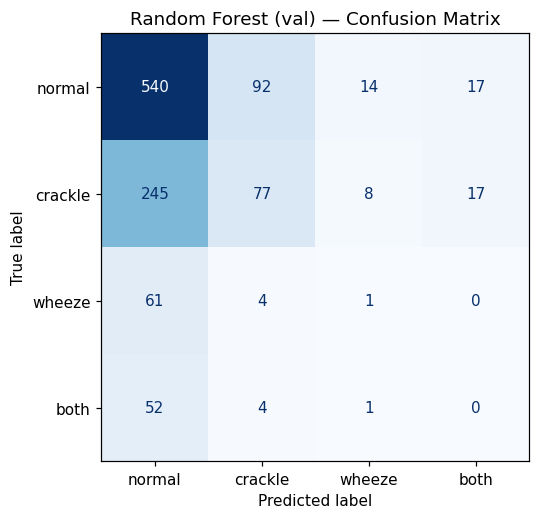

In [6]:
le = LabelEncoder()
le.fit(LABELS)

y_train_enc = le.transform(y_train)

rf = RandomForestClassifier(
    n_estimators=300, # Random Forest with 300 decision trees.
    class_weight="balanced", # Give more importance to minority classes during training.
    random_state=SEED,
    n_jobs=-1,# Use all available CPU cores.
)
rf.fit(X_train, y_train_enc) # Train the Random Forest

y_val_pred = le.inverse_transform(rf.predict(X_val)) # Make predictions on validation data

rf_val_scores = evaluate_and_report(y_val, y_val_pred, "Random Forest (val)")
log_result("Random Forest + MFCC", "val", rf_val_scores)

## **5. Baseline 2 — Simple CNN on spectrograms**

Unlike the Random Forest, a CNN can consume the full 2D `(128, ~801)` spectrogram directly — no averaging away the time axis. This is a **baseline**, not a competitor to AST — kept deliberately small (3 conv blocks) so it trains in minutes and gives a meaningfully different comparison point without over-engineering.

### 5.1 Dataset and DataLoader

Spectrograms are loaded lazily inside `Dataset.__getitem__` rather than loading the entire dataset into memory at once.

The DataLoader groups samples into batches for training and evaluation. This keeps memory use more manageable as the dataset grows.


In [ ]:
class LungSoundDataset(Dataset):
    def __init__(self, df, label_encoder):
        self.df = df.reset_index(drop=True)
        self.le = label_encoder

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec = np.load(row["spectrogram_path"])            # (128, ~801)

        # Per-sample standardization used in this baseline experiment.
        # Keep this consistent when reproducing the reported results.
        spec = (spec - spec.mean()) / (spec.std() + 1e-6)

        x = torch.from_numpy(spec).unsqueeze(0).float()    # (1, 128, ~801) -- channel dim for Conv2d
        y = torch.tensor(self.le.transform([row["label"]])[0], dtype=torch.long)
        return x, y


train_ds = LungSoundDataset(train_df, le)
val_ds   = LungSoundDataset(val_df, le)
test_ds  = LungSoundDataset(test_df, le)

# DataLoader as wrapping a dataset to provide iterable access to the samples.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS) # worker processes to load/preprocess samples.
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# sanity check
xb, yb = next(iter(train_loader))
print("Batch shape:", xb.shape)   # (BATCH_SIZE, 1, 128, ~801)
print("Label shape:", yb.shape)

Batch shape: torch.Size([16, 1, 128, 801])
Label shape: torch.Size([16])


### **5.2 Model**

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes=len(LABELS)):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                    # 128x801 -> 64x400

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                    # -> 32x200

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                    # -> 16x100

            nn.AdaptiveAvgPool2d((4, 4)),       # fixed-size output regardless
                                                 # of minor input-shape drift
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = SimpleCNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

Model parameters: 155,236


### 5.3 Class-weighted loss

Same imbalance problem as the Random Forest, different mechanism: instead of resampling, the loss function itself penalizes mistakes on rare classes more heavily, computed directly from the training set's actual class frequencies rather than guessed.

In [9]:
class_counts = train_df["label"].value_counts().reindex(LABELS).fillna(0)
class_weights = (1.0 / class_counts).values
class_weights = class_weights / class_weights.sum() * len(LABELS)  # normalize
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print(dict(zip(LABELS, class_weights.cpu().numpy().round(3))))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

{'normal': np.float32(0.331), 'crackle': np.float32(0.616), 'wheeze': np.float32(1.049), 'both': np.float32(2.003)}


### 5.4 Training loop

**Why checkpoint by val ICBHI Score and not val loss:** on an imbalanced dataset, loss and the metric you actually care about can diverge -- a model can keep lowering its loss on the majority "Normal" class while Sensitivity on the rare classes stagnates or even drops. Selecting the checkpoint by the same metric you'll report avoids shipping a model that looks good on the wrong number.

**Why early stopping:** with only ~4,500 training cycles, this small CNN can start overfitting well before `MAX_EPOCHS` -- stopping when val ICBHI Score hasn't improved for `EARLY_STOP_PATIENCE` epochs avoids wasting compute and avoids picking an overfit late-epoch checkpoint.

In [10]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_true, all_pred = [], []

    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            all_true.extend(le.inverse_transform(yb.cpu().numpy()))
            all_pred.extend(le.inverse_transform(preds.cpu().numpy()))

    avg_loss = total_loss / len(loader.dataset) # average loss for the entire dataset.
    scores = icbhi_score(all_true, all_pred)
    return avg_loss, scores


history = {"train_loss": [], "val_loss": [], "val_icbhi_score": []}
best_val_score = -1
epochs_without_improvement = 0
best_checkpoint_path = CHECKPOINT_DIR / "cnn_best.pt"



for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, _ = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_scores = run_epoch(model, val_loader, criterion, optimizer=None)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_icbhi_score"].append(val_scores["icbhi_score"])

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_ICBHI_score={val_scores['icbhi_score']*100:.2f}%")

    if val_scores["icbhi_score"] > best_val_score:
        best_val_score = val_scores["icbhi_score"]
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_checkpoint_path)
        print(f"  -> new best (saved to {best_checkpoint_path.name})")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch} (no improvement for {EARLY_STOP_PATIENCE} epochs)")
        break

Epoch 01 | train_loss=1.0943 | val_loss=1.0725 | val_ICBHI_score=50.00%
  -> new best (saved to cnn_best.pt)
Epoch 02 | train_loss=1.0651 | val_loss=1.0167 | val_ICBHI_score=50.00%
Epoch 03 | train_loss=1.0487 | val_loss=1.0236 | val_ICBHI_score=50.00%
Epoch 04 | train_loss=1.0452 | val_loss=0.9850 | val_ICBHI_score=50.00%
Epoch 05 | train_loss=1.0375 | val_loss=1.1017 | val_ICBHI_score=48.87%
Epoch 06 | train_loss=1.0244 | val_loss=1.0811 | val_ICBHI_score=51.82%
  -> new best (saved to cnn_best.pt)
Epoch 07 | train_loss=1.0208 | val_loss=1.0394 | val_ICBHI_score=48.14%
Epoch 08 | train_loss=1.0081 | val_loss=1.1565 | val_ICBHI_score=48.47%
Epoch 09 | train_loss=0.9923 | val_loss=1.3899 | val_ICBHI_score=53.72%
  -> new best (saved to cnn_best.pt)
Epoch 10 | train_loss=0.9906 | val_loss=1.0128 | val_ICBHI_score=48.71%
Epoch 11 | train_loss=0.9584 | val_loss=1.1723 | val_ICBHI_score=50.46%
Epoch 12 | train_loss=0.9650 | val_loss=1.0338 | val_ICBHI_score=51.57%
Epoch 13 | train_loss=0.9

### 5.5 Training curves

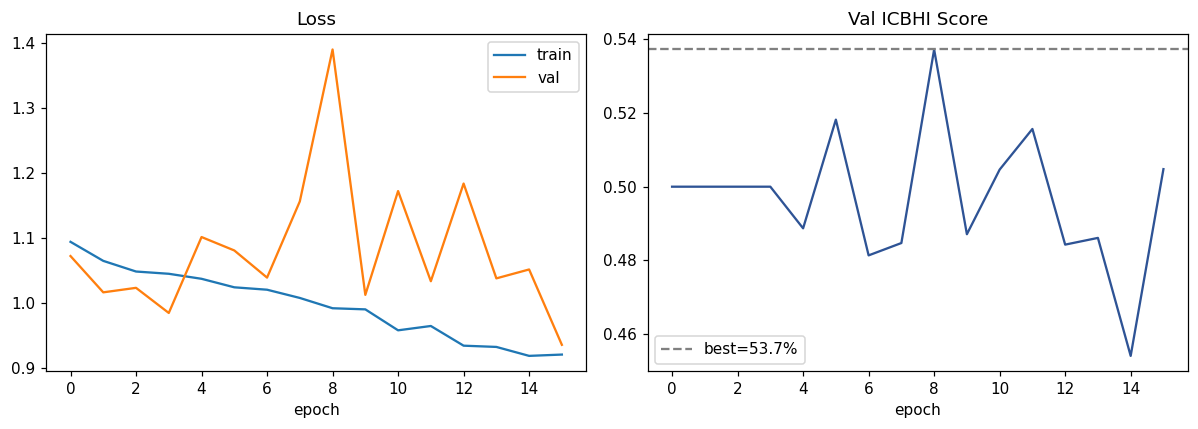

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["val_icbhi_score"], color="#2E5395")
axes[1].axhline(best_val_score, linestyle="--", color="gray", label=f"best={best_val_score*100:.1f}%")
axes[1].set_title("Val ICBHI Score")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.6 Evaluate the best checkpoint (val set)

Reload the best-scoring checkpoint (not whatever the model's weights happen to be after the last epoch -- those may already be past the point early stopping flagged as best) before reporting.

--- CNN (val, best checkpoint) ---
Sensitivity: 78.94%
Specificity: 28.51%
ICBHI Score:  53.72%

              precision    recall  f1-score   support

      normal       0.66      0.29      0.40       663
     crackle       0.00      0.00      0.00       347
      wheeze       0.07      0.83      0.12        66
        both       0.00      0.00      0.00        57

    accuracy                           0.22      1133
   macro avg       0.18      0.28      0.13      1133
weighted avg       0.39      0.22      0.24      1133



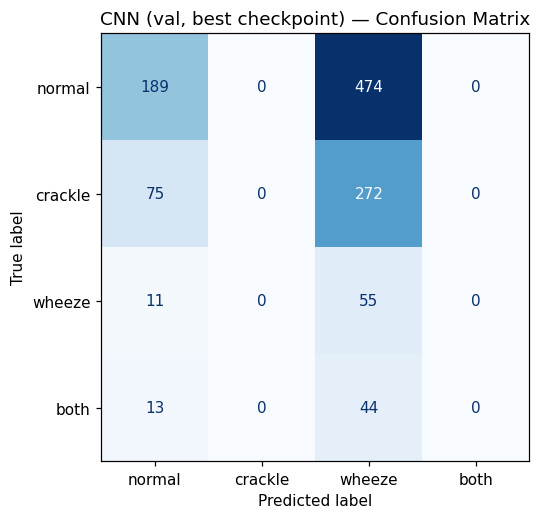

In [12]:
model.load_state_dict(torch.load(best_checkpoint_path))
model.eval()

_, cnn_val_scores_raw = run_epoch(model, val_loader, criterion, optimizer=None)

# rebuild predictions explicitly for the confusion-matrix/report view
all_true, all_pred = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        preds = model(xb).argmax(dim=1).cpu().numpy()
        all_true.extend(le.inverse_transform(yb.numpy()))
        all_pred.extend(le.inverse_transform(preds))

cnn_val_scores = evaluate_and_report(all_true, all_pred, "CNN (val, best checkpoint)")
log_result("Simple CNN", "val", cnn_val_scores, notes=f"best epoch by val ICBHI Score")

## **6. Final test-set evaluation**

**Touched exactly once, here, for both models.** This is the number that goes in the report -- val was only ever used for model selection and early stopping above.

--- Random Forest (TEST) ---
Sensitivity: 18.70%
Specificity: 91.40%
ICBHI Score:  55.05%

              precision    recall  f1-score   support

      normal       0.63      0.91      0.74       709
     crackle       0.31      0.05      0.09       298
      wheeze       0.08      0.07      0.07       104
        both       0.00      0.00      0.00        74

    accuracy                           0.57      1185
   macro avg       0.25      0.26      0.23      1185
weighted avg       0.46      0.57      0.47      1185



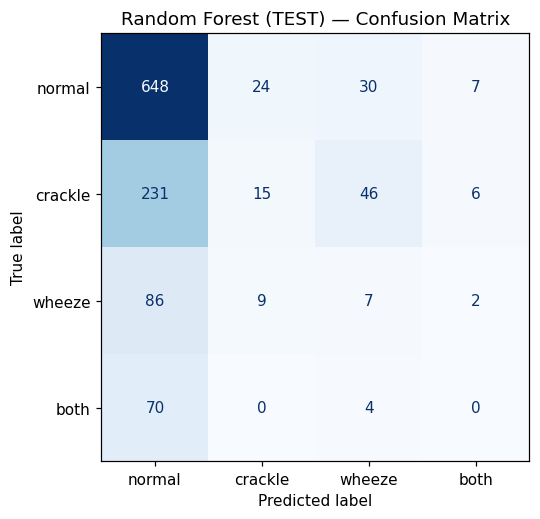

--- CNN (TEST) ---
Sensitivity: 74.58%
Specificity: 41.89%
ICBHI Score:  58.23%

              precision    recall  f1-score   support

      normal       0.71      0.42      0.53       709
     crackle       0.00      0.00      0.00       298
      wheeze       0.11      0.78      0.19       104
        both       0.00      0.00      0.00        74

    accuracy                           0.32      1185
   macro avg       0.20      0.30      0.18      1185
weighted avg       0.43      0.32      0.33      1185



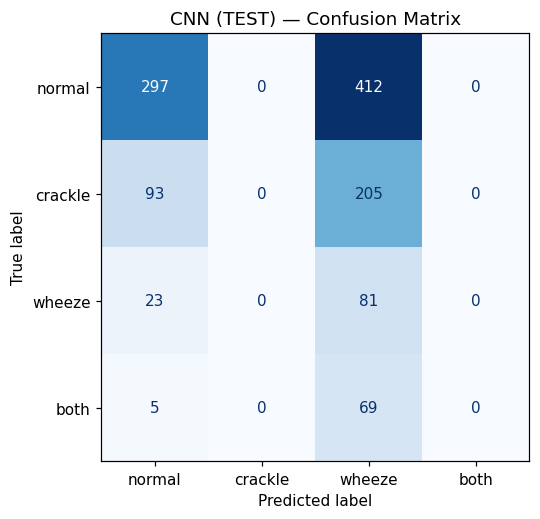

In [13]:
# --- Random Forest, test set ---
X_test, y_test = build_mfcc_features(test_df)
y_test_pred_rf = le.inverse_transform(rf.predict(X_test))
rf_test_scores = evaluate_and_report(y_test, y_test_pred_rf, "Random Forest (TEST)")
log_result("Random Forest + MFCC", "test", rf_test_scores)


# --- CNN, test set ---
all_true, all_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        preds = model(xb).argmax(dim=1).cpu().numpy()
        all_true.extend(le.inverse_transform(yb.numpy()))
        all_pred.extend(le.inverse_transform(preds))

cnn_test_scores = evaluate_and_report(all_true, all_pred, "CNN (TEST)")
log_result("Simple CNN", "test", cnn_test_scores)

## **7. Baseline Results Summary**

In [14]:
results_df = pd.DataFrame(results_log)
results_df["sensitivity"] = (results_df["sensitivity"] * 100).round(2)
results_df["specificity"] = (results_df["specificity"] * 100).round(2)
results_df["icbhi_score"] = (results_df["icbhi_score"] * 100).round(2)

display_cols = ["model", "split", "sensitivity", "specificity", "icbhi_score", "notes"]
results_df[display_cols].to_csv(RESULTS_CSV, index=False)
results_df[display_cols]

,model,split,sensitivity,specificity,icbhi_score,notes
0,Random Forest + MFCC,val,23.83,81.45,52.64,
1,Simple CNN,val,78.94,28.51,53.72,best epoch by val ICBHI Score
2,Random Forest + MFCC,test,18.70,91.40,55.05,
3,Simple CNN,test,74.58,41.89,58.23,


## **8. Phase 2 Summary**

This phase established two baseline approaches for four-class respiratory sound classification.

### Completed experiments

* MFCC-based feature extraction followed by Random Forest classification.
* A compact CNN trained directly on cached Log-Mel spectrograms.
* Class-weighted cross-entropy loss for the CNN.
* Checkpoint selection using validation ICBHI score and early stopping.
* Validation and test evaluation using a shared ICBHI-score implementation.
* Four-class classification reports and confusion matrices.
* Training curves and a CSV containing the recorded results.

### Evaluation caveat

These experiments use the project's patient-level 70/15/15 train/validation/test split. Their results provide an internal baseline for subsequent experiments under the same protocol. Comparisons with published results require compatible splits, preprocessing, metrics and evaluation procedures.

### Outputs

* `results.csv`: validation and test metrics for both baseline models.
* `checkpoints/cnn_best.pt`: CNN weights selected using validation ICBHI score.

### Next phase

Phase 3 investigates AST fine-tuning and compares training strategies, including cross-entropy, focal loss and supervised contrastive learning. The resulting experiments should use clearly documented evaluation protocols and preserve the distinction between validation and test results.
